<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>51095 למידה מונחית חיזוקים</p>
<p>פרויקט סופי</p>
<p>שם: נדב פיירמן שטרן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נושא: מימוש MCTS מאפס למשחקי לוח לשני שחקנים — איקס עיגול כסביבת אימות עם פתרון מושלם ידוע, וארבע בשורה מוקטן (4×5) כסביבה המרכזית.</p>
<p>שאלת המחקר: כמה חיפוש נדרש כדי להתקרב למשחק מושלם, ומה משתפר כשרשת שלומדת ממשחק עצמי מחליפה את הסימולציה האקראית.</p>
<p>גישה: שלב 1 — MCTS טהור מול אקראי, חמדן ו-minimax, עם אבלציות על מספר סימולציות ועומק rollout. שלב 2 — רשת policy+value בהערכת העלים, ברוח AlphaZero.</p>
<p>מדדים: תוצאות מול שחקני הבסיס, הפסדים מול שחקן מושלם, אחוז מהלכים אופטימליים, עקומות למידה. הצלחה: אפס הפסדים מול מושלם באיקס עיגול; יתרון על חיפוש טהור בתקציב שווה בארבע בשורה.</p>
<p>הסביבה: מצב = לוח + תור; פעולה = משבצת ריקה / עמודה לא מלאה (האסימון נופל לתחתית); תגמול בסיום בלבד: 1 / 0 / מינוס 1; סיום ברצף מנצח או לוח מלא.</p>
<p>כל הקוד במחברת, הרצה מלאה משחזרת את הכול; גרפים באנגלית (מגבלת עברית ב-matplotlib).</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא — כל הייבוא מרוכז כאן:</p>
<ul>
<li>math — שורש ולוגריתם לנוסחאות UCT/PUCT</li>
<li>random — בחירות אקראיות של שחקנים וסימולציות</li>
<li>time — מדידת זמני אימון</li>
<li>pickle — שמירה/טעינה של תוצאות (מנגנון RETRAIN)</li>
<li>numpy — לוח ארבע בשורה, וקטורי מדיניות, סטטיסטיקה</li>
<li>matplotlib — גרפים; סגנון ggplot נקבע בשורה האחרונה</li>
<li>seaborn — מפות החום של המדיניות בשלב 2</li>
<li>torch, nn, F — הרשת ואימונה בשלב 2</li>
</ul>
</div>

In [ ]:
import math
import random
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

plt.style.use("ggplot")

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרות — כל הפרמטרים במקום אחד:</p>

<p>סביבה וכללי</p>
<ul>
<li>SEED — הזרע הראשי; מקובע בסוף התא ל-random, numpy ו-torch</li>
<li>C4_ROWS — מספר שורות הלוח, 4</li>
<li>C4_COLS — מספר עמודות הלוח, 5</li>
<li>C4_CONNECT — אורך הרצף המנצח, 4</li>
</ul>

<p>MCTS ושלב 1</p>
<ul>
<li>UCT_C — קבוע החקר; שורש 2, הערך התאורטי</li>
<li>N_SIMULATIONS — תקציב סימולציות ברירת מחדל למהלך</li>
<li>EVAL_GAMES — מספר משחקים בהערכה כללית</li>
<li>VALIDATION_GAMES — מספר משחקים באימות מול minimax</li>
<li>SEEDS — זרעי החזרה לאבלציות</li>
<li>SIM_COUNTS — תקציבי הסימולציות שנבחנים באבלציה</li>
<li>ABLATION_GAMES — משחקים לכל נקודה באבלציה</li>
</ul>

<p>הרשת ושלב 2</p>
<ul>
<li>PUCT_C — קבוע החקר ב-PUCT</li>
<li>HIDDEN_SIZE — רוחב השכבה החבויה ברשת</li>
<li>LEARNING_RATE — קצב הלמידה של Adam</li>
<li>TRAIN_EPOCHS — מספר מעברים על כל batch באימון</li>
<li>BATCH_SIZE — גודל מיני-batch באימון</li>
<li>BUFFER_SIZE — המאגר המתגלגל (הסבר בתא alphazero_training)</li>
<li>TEMPERATURE_MOVES — דגימת מהלכי פתיחה (הסבר בתא self_play_game)</li>
<li>DIRICHLET_ALPHA — פרמטר הצורה של רעש דיריכלה בשורש</li>
<li>DIRICHLET_EPS — משקל הרעש מול ה-prior המקורי</li>
<li>SELFPLAY_SIMS — תקציב סימולציות במשחק העצמי</li>
<li>TRAIN_ITERATIONS — מספר סבבי האימון</li>
<li>GAMES_PER_ITERATION — משחקי משחק-עצמי בכל סבב</li>
<li>EVAL_GAMES_PER_ITERATION — משחקי הערכה אחרי כל סבב</li>
</ul>

<p>מערכת</p>
<ul>
<li>RETRAIN — True מריץ ושומר לקבצים; False טוען מהם</li>
<li>DEVICE — GPU אם קיים, אחרת CPU</li>
</ul>

<p>בחירת הערכים: תקציבי חיפוש ועומק — מהאבלציות; קבועי החקר — מהספרות; היפר-פרמטרי הרשת — לתקציב של דקות, מאומתים מול פתרון האמת באיקס עיגול.</p>
</div>

In [ ]:
SEED = 42
C4_ROWS = 4
C4_COLS = 5
C4_CONNECT = 4
UCT_C = math.sqrt(2)
N_SIMULATIONS = 200
EVAL_GAMES = 200
VALIDATION_GAMES = 50
SEEDS = [0, 1, 2, 3, 4]
SIM_COUNTS = [10, 25, 50, 100, 200, 400]
ABLATION_GAMES = 30
PUCT_C = 1.5
HIDDEN_SIZE = 64
LEARNING_RATE = 1e-3
TRAIN_EPOCHS = 4
BATCH_SIZE = 64
BUFFER_SIZE = 2500
TEMPERATURE_MOVES = 2
DIRICHLET_ALPHA = 0.3
DIRICHLET_EPS = 0.25
SELFPLAY_SIMS = 60
TRAIN_ITERATIONS = 15
GAMES_PER_ITERATION = 30
EVAL_GAMES_PER_ITERATION = 15
RETRAIN = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סביבות המשחק: ממשק אחיד של חמש פונקציות לשני המשחקים; שחקנים 1/מינוס 1, משבצת ריקה 0. מומשו עצמאית ולא ב-Gymnasium: אין שכפול מצבים זול, אין תמיכה בדו-שחקנים, והמשחקים לא קיימים שם. מותר לפי מסמך הפרויקט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה TicTacToe — לוח 3×3 כרשימה שטוחה באורך 9:</p>
<ul>
<li>LINES — שמונה השלשות המנצחות: 3 שורות, 3 עמודות, 2 אלכסונים</li>
<li>init — לוח ריק, שחקן 1 פותח</li>
<li>render — הדפסה כ-X/O/נקודה</li>
<li>clone — עותק בלתי תלוי, לחמדן ולסימולציות</li>
<li>legal_moves — אינדקסי המשבצות הריקות</li>
<li>play — מציבה סימן, מעבירה תור בהיפוך</li>
<li>winner — סכום 3/מינוס 3 = ניצחון; לוח מלא = תיקו; אחרת None</li>
</ul>
</div>

In [ ]:
class TicTacToe:
    LINES = ((0, 1, 2), (3, 4, 5), (6, 7, 8),
             (0, 3, 6), (1, 4, 7), (2, 5, 8),
             (0, 4, 8), (2, 4, 6))

    def __init__(self):
        self.board = [0] * 9
        self.player = 1

    def clone(self):
        g = TicTacToe()
        g.board = self.board[:]
        g.player = self.player
        return g

    def legal_moves(self):
        return [i for i in range(9) if self.board[i] == 0]

    def play(self, move):
        self.board[move] = self.player
        self.player = -self.player

    def winner(self):
        for a, b, c in self.LINES:
            s = self.board[a] + self.board[b] + self.board[c]
            if s == 3:
                return 1
            if s == -3:
                return -1
        if 0 not in self.board:
            return 0
        return None

    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        for r in range(3):
            print(" ".join(symbols[self.board[3 * r + c]] for c in range(3)))
        print()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המחלקה ConnectFour — ארבע בשורה מוקטן, מטריצה 4×5, שורה 0 עליונה:</p>
<ul>
<li>init — לוח ריק, שחקן 1 פותח, מהלך אחרון None</li>
<li>clone — עותק בלתי תלוי של המטריצה והמהלך האחרון</li>
<li>legal_moves — עמודות שהמשבצת העליונה שלהן ריקה</li>
<li>play — כבידה: האסימון נופל לשורה הפנויה הנמוכה ביותר, נשמר כמהלך אחרון, התור עובר</li>
<li>winner — בודקת רק סביב המהלך האחרון, בארבעה כיוונים משני צדדיו; רצף 4 = ניצחון, לוח מלא = תיקו, אחרת None</li>
<li>render — הדפסת הלוח ומתחתיו מספרי העמודות</li>
</ul>
</div>

In [ ]:
class ConnectFour:
    def __init__(self, rows=C4_ROWS, cols=C4_COLS, connect=C4_CONNECT):
        self.rows = rows
        self.cols = cols
        self.connect = connect
        self.board = np.zeros((rows, cols), dtype=int)
        self.player = 1
        self.last_move = None

    def clone(self):
        g = ConnectFour(self.rows, self.cols, self.connect)
        g.board = self.board.copy()
        g.player = self.player
        g.last_move = self.last_move
        return g

    def legal_moves(self):
        return [c for c in range(self.cols) if self.board[0, c] == 0]

    def play(self, col):
        row = max(r for r in range(self.rows) if self.board[r, col] == 0)
        self.board[row, col] = self.player
        self.last_move = (row, col, self.player)
        self.player = -self.player

    def winner(self):
        if self.last_move is None:
            return None
        row, col, player = self.last_move
        for dr, dc in ((0, 1), (1, 0), (1, 1), (1, -1)):
            count = 1
            for sign in (1, -1):
                r, c = row + sign * dr, col + sign * dc
                while 0 <= r < self.rows and 0 <= c < self.cols and self.board[r, c] == player:
                    count += 1
                    r += sign * dr
                    c += sign * dc
            if count >= self.connect:
                return player
        if len(self.legal_moves()) == 0:
            return 0
        return None

    def render(self):
        symbols = {1: "X", -1: "O", 0: "."}
        for r in range(self.rows):
            print(" ".join(symbols[int(self.board[r, c])] for c in range(self.cols)))
        print(" ".join(str(c) for c in range(self.cols)))
        print()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שחקני בסיס: שחקן הוא פונקציה שמקבלת מצב ומחזירה מהלך חוקי. כך גם אלגוריתמי החיפוש ייארזו כפונקציות זהות בממשק, וכל הסוכנים יוכלו להתמודד זה מול זה באותו מנגנון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>random_player — בוחר מהלך אקראי אחיד. קו הבסיס התחתון; כל אלגוריתם חייב לגבור עליו.</p>
</div>

In [ ]:
def random_player(game):
    return random.choice(game.legal_moves())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>winning_moves — מאתר מהלכים שמנצחים מיד: על עותק משוכפל, בודק לכל מהלך חוקי אם הביצוע שלו מנצח.</p>
</div>

In [ ]:
def winning_moves(game, player):
    moves = []
    for move in game.legal_moves():
        g = game.clone()
        g.player = player
        g.play(move)
        if g.winner() == player:
            moves.append(move)
    return moves

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>greedy_player — שלושה שלבים: מנצח מיד אם אפשר, אחרת חוסם ניצחון מיידי של היריב, אחרת אקראי. חזק מהאקראי אך עיוור למלכודות כפולות (שני איומים במקביל) — בדיוק החולשה שחיפוש קדימה מנצל.</p>
</div>

In [ ]:
def greedy_player(game):
    wins = winning_moves(game, game.player)
    if wins:
        return random.choice(wins)
    blocks = winning_moves(game, -game.player)
    if blocks:
        return random.choice(blocks)
    return random.choice(game.legal_moves())

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בדיקת שפיות: משחק בודד מלא בכל סביבה, ואז סטטיסטיקה מול ערכים ידועים מהספרות — לוודא שהתשתית תקינה לפני המעבר לאלגוריתם.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>play_game — מריץ משחק שלם: כל תור בוחר סוכן לפי זהות השחקן ומבצע את מהלכו; verbose מדפיס את הלוח. מחזיר תוצאה מנקודת מבט הפותח: 1 ניצחון, מינוס 1 הפסד, 0 תיקו.</p>
</div>

In [ ]:
def play_game(game, agent_plus, agent_minus, verbose=False):
    while game.winner() is None:
        agent = agent_plus if game.player == 1 else agent_minus
        game.play(agent(game))
        if verbose:
            game.render()
    return game.winner()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>match_stats — מריץ n משחקים בין שני סוכנים (משחק חדש בכל פעם), סופר נצחונות פותח/שני/תיקו.</p>
</div>

In [ ]:
def match_stats(game_class, agent_plus, agent_minus, n_games):
    counts = {1: 0, -1: 0, 0: 0}
    for _ in range(n_games):
        counts[play_game(game_class(), agent_plus, agent_minus)] += 1
    return counts

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>two_sided_stats — הערכה סימטרית: חצי מהמשחקים כפותח, חצי כשני. מנטרלת יתרון פותח; כל ההשוואות בהמשך דרכה.</p>
</div>

In [ ]:
def two_sided_stats(game_class, agent, opponent, n_games):
    as_first = match_stats(game_class, agent, opponent, n_games)
    as_second = match_stats(game_class, opponent, agent, n_games)
    wins = as_first[1] + as_second[-1]
    losses = as_first[-1] + as_second[1]
    draws = as_first[0] + as_second[0]
    return wins, losses, draws

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>board_grid — מחזירה עבור משחק נתון: מספר שורות, מספר עמודות, ופונקציה לשליפת תוכן משבצת (r,c). מבודדת את הבדל הייצוג בין הלוח השטוח של TicTacToe למטריצה של ConnectFour.</p>
</div>

In [ ]:
def board_grid(game):
    if isinstance(game, TicTacToe):
        return 3, 3, lambda r, c: game.board[3 * r + c]
    return game.rows, game.cols, lambda r, c: game.board[r, c]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>render_move_sequence — הצגת משחק שלם כרצף לוחות מוקטן: כל מהלך נשמר כצילום מצב, והלוחות מודפסים בשורות של boards_per_row עם מספר המהלך צמוד לכל לוח. משמשת בכל הדגמות המשחק במחברת.</p>
</div>

In [ ]:
def render_move_sequence(game, agent_plus, agent_minus, boards_per_row=3):
    symbols = {1: "X", -1: "O", 0: "."}
    snapshots = []
    move_num = 0
    while game.winner() is None:
        agent = agent_plus if game.player == 1 else agent_minus
        game.play(agent(game))
        move_num += 1
        snapshots.append((move_num, game.clone()))
    rows, cols, _ = board_grid(game)
    num_width = len(str(len(snapshots)))
    for start in range(0, len(snapshots), boards_per_row):
        group = snapshots[start:start + boards_per_row]
        for r in range(rows):
            line = ""
            for num, snap in group:
                _, _, get = board_grid(snap)
                row = " ".join(symbols[get(r, c)] for c in range(cols))
                prefix = f"{num:>{num_width}})  " if r == rows // 2 else " " * (num_width + 3)
                line += f"{prefix}{row}     "
            print(line)
        print()
    return game.winner()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק הדגמה: שני שחקנים אקראיים באיקס עיגול, לוח מודפס אחרי כל מהלך. זרע מקובע לשחזוריות.</p>
</div>

In [ ]:
random.seed(SEED)
result = render_move_sequence(TicTacToe(), random_player, random_player, boards_per_row=5)
print("result:", result)

    . X .         O X .         O X .         O X .         O X .     
1)  . . .     2)  . . .     3)  . . .     4)  . O .     5)  X O .     
    . . .         . . .         . X .         . X .         . X .     

    O X .         O X X         O X X         O X X     
6)  X O O     7)  X O O     8)  X O O     9)  X O O     
    . X .         . X .         O X .         O X X     

result: 0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק הדגמה בארבע בשורה בין שני שחקנים אקראיים, עם הדפסת הלוח הסופי והתוצאה.</p>
</div>

In [ ]:
random.seed(SEED)
result = render_move_sequence(ConnectFour(), random_player, random_player, boards_per_row=5)
print("result:", result)

     . . . . .          . . . . .          . . . . .          . . . . .          . . . . .     
     . . . . .          . . . . .          . . . . .          . . . . .          . . . . .     
 1)  . . . . .      2)  O . . . .      3)  O . . . .      4)  O . . . .      5)  O X . . .     
     X . . . .          X . . . .          X . X . .          X O X . .          X O X . .     

     . . . . .          . . . . .          . . . . .          X . . . .          X . . . .     
     . O . . .          X O . . .          X O . . .          X O . . .          X O . . .     
 6)  O X . . .      7)  O X . . .      8)  O X . . .      9)  O X . . .     10)  O X . . O     
     X O X . .          X O X . .          X O X . O          X O X . O          X O X . O     

     X X . . .          X X . . .          X X . . .          X X O . .          X X O . .     
     X O . . .          X O . . .          X O X . .          X O X . .          X O X . .     
11)  O X . . O     12)  O X O . O     

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טבלת סטטיסטיקה על כל צירופי שחקני הבסיס בשתי הסביבות — אחוזי ניצחון לפותח, לשני ותיקו, לאימות התשתית לפני המעבר לאלגוריתם.</p>
</div>

In [ ]:
random.seed(SEED)
matchups = ((random_player, random_player, "random vs random"),
            (greedy_player, random_player, "greedy vs random"),
            (random_player, greedy_player, "random vs greedy"),
            (greedy_player, greedy_player, "greedy vs greedy"))

for game_class, game_name in ((TicTacToe, "tic-tac-toe"), (ConnectFour, "connect-four 5x4")):
    for agent_plus, agent_minus, label in matchups:
        counts = match_stats(game_class, agent_plus, agent_minus, EVAL_GAMES)
        n = EVAL_GAMES
        print(f"{game_name} | {label}: first {100 * counts[1] / n:.1f}%  "
              f"second {100 * counts[-1] / n:.1f}%  draw {100 * counts[0] / n:.1f}%")

tic-tac-toe | random vs random: first 57.5%  second 27.5%  draw 15.0%
tic-tac-toe | greedy vs random: first 91.0%  second 0.5%  draw 8.5%
tic-tac-toe | random vs greedy: first 8.0%  second 68.5%  draw 23.5%
tic-tac-toe | greedy vs greedy: first 29.5%  second 16.5%  draw 54.0%
connect-four 5x4 | random vs random: first 43.0%  second 29.5%  draw 27.5%
connect-four 5x4 | greedy vs random: first 71.5%  second 4.0%  draw 24.5%
connect-four 5x4 | random vs greedy: first 7.5%  second 62.0%  draw 30.5%
connect-four 5x4 | greedy vs greedy: first 24.5%  second 26.5%  draw 49.0%


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: תואם לצפוי. איקס עיגול — פותח אקראי מנצח כ-58% כצפוי; חמדן גובר ברוב מכריע ומפסיד רק לעיתים נדירות ממלכודות כפולות. ארבע בשורה — שיעור תיקו גבוה יותר, סימן שהלוח הקטן נוטה לתיקו. התשתית מאומתת, אפשר לעבור לאלגוריתם.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלב 1 — אלגוריתם MCTS:</p>
<p>לפני כל מהלך בונים עץ חיפוש בלולאה של ארבעה שלבים, מאות פעמים: בחירה (UCT, איזון ניצול-חקר), הרחבה (צומת חדש), סימולציה (מהלכים אקראיים עד תוצאה), עדכון לאחור (עדכון ביקורים וניקוד במסלול). נבחר המהלך עם הכי הרבה ביקורים בשורש.</p>
<p>UCT = ניקוד ממוצע + בונוס חקר (שורש לוג ביקורי הורה חלקי ביקורי ילד, כפול קבוע) — יישום UCB מעולם ה-bandits.</p>
<p>במשחק שני שחקנים: ניצחון אחד הוא הפסד השני, לכן הניקוד בכל צומת מנקודת מבט השחקן שהוביל אליו — שקול להיפוך סימן בין רמות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>MCTSNode — צומת בעץ: מצב, הורה, המהלך שהוביל אליו, ילדים, מהלכים שטרם נוסו, מונה ביקורים וניקוד מצטבר. הניקוד מנקודת מבט השחקן שהוביל לצומת: 1 ניצחון, 0.5 תיקו, 0 הפסד.</p>
</div>

In [ ]:
class MCTSNode:
    def __init__(self, game, parent=None, move=None):
        self.game = game
        self.parent = parent
        self.move = move
        self.children = []
        self.untried_moves = list(game.legal_moves()) if game.winner() is None else []
        self.visits = 0
        self.score = 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>uct_value — ניקוד ממוצע (ניצול) + בונוס שגדל ככל שהילד בוקר פחות (חקר). c גדול מעדיף חקר, c קטן מעדיף ניצול.</p>
</div>

In [ ]:
def uct_value(child, parent_visits, c):
    exploit = child.score / child.visits
    explore = c * math.sqrt(math.log(parent_visits) / child.visits)
    return exploit + explore

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>select — יורדים מהשורש, בוחרים תמיד את הילד עם UCT הגבוה ביותר, עד צומת עם מהלכים שטרם נוסו או ללא ילדים.</p>
</div>

In [ ]:
def select(node, c):
    while not node.untried_moves and node.children:
        node = max(node.children, key=lambda ch: uct_value(ch, node.visits, c))
    return node

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>expand — שולפים מהלך אקראי מהלא-נוסו, משכפלים ומבצעים על העותק, ומוסיפים כילד חדש לעץ.</p>
</div>

In [ ]:
def expand(node):
    move = node.untried_moves.pop(random.randrange(len(node.untried_moves)))
    next_game = node.game.clone()
    next_game.play(move)
    child = MCTSNode(next_game, parent=node, move=move)
    node.children.append(child)
    return child

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>rollout — מהלכים אקראיים לגמרי עד סיום, מוחזרת התוצאה. רועש במשחק בודד, אך ממוצע על מאות סימולציות הופך לאומדן שימושי — עקרון הערכת מונטה קרלו.</p>
</div>

In [ ]:
def rollout(game):
    g = game.clone()
    while g.winner() is None:
        g.play(random.choice(g.legal_moves()))
    return g.winner()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>backpropagate — מטפסים מהצומת שהוערך עד השורש: ביקורים+1 וניקוד מתעדכן מנקודת מבט השחקן שביצע את המהלך אליו (היפוך משחקן התור).</p>
</div>

In [ ]:
def backpropagate(node, winner):
    while node is not None:
        node.visits += 1
        mover = -node.game.player
        if winner == mover:
            node.score += 1.0
        elif winner == 0:
            node.score += 0.5
        node = node.parent

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_search — שורש מהמצב הנוכחי, ארבעת השלבים n_simulations פעמים, ואז המהלך עם הכי הרבה ביקורים (יציב יותר מניקוד ממוצע, כי משקף גם ביטחון).</p>
</div>

In [ ]:
def mcts_search(game, n_simulations=N_SIMULATIONS, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout(node.game)
        backpropagate(node, winner)
    return max(root.children, key=lambda ch: ch.visits).move

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_root_visits — כמו mcts_search, אך מחזירה מילון ביקורים לכל ילדי השורש — התפלגות שמשקפת עד כמה כל מהלך נראה טוב.</p>
</div>

In [ ]:
def mcts_root_visits(game, n_simulations=N_SIMULATIONS, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout(node.game)
        backpropagate(node, winner)
    return {child.move: child.visits for child in root.children}

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_player — אורזת את החיפוש כפונקציית שחקן (מוסכמת המחברת): מקבלת תקציב סימולציות, מחזירה פונקציה מצב→מהלך. כך אפשר להשוות עוצמות שונות, למשל mcts_player(50) מול mcts_player(400).</p>
</div>

In [ ]:
def mcts_player(n_simulations=N_SIMULATIONS, c=UCT_C):
    def player(game):
        return mcts_search(game, n_simulations, c)
    return player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שחקן מושלם באיקס עיגול — minimax עם זיכרון: איקס עיגול קטן מספיק לפתור במדויק, ולכן משמש סביבת אימות — מול שחקן מושלם, סוכן תקין לא אמור להפסיד, ומשחק מושלם משני הצדדים מסתיים בתיקו. ממומש רק לאיקס עיגול; בארבע בשורה מרחב המצבים גדול מכדי לפתור בזמן סביר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>minimax_value — רקורסיבי: תוצאה סופית מחזירה עצמה, אחרת שחקן 1 בוחר מקסימום מבין ההמשכים ויריבו מינימום. MINIMAX_CACHE שומר כל מצב שחושב — כ-5,500 מצבים חוקיים באיקס עיגול, כל אחד פעם אחת בלבד.</p>
</div>

In [ ]:
MINIMAX_CACHE = {}


def minimax_value(game):
    key = (tuple(game.board), game.player)
    if key in MINIMAX_CACHE:
        return MINIMAX_CACHE[key]
    w = game.winner()
    if w is not None:
        value = w
    else:
        values = []
        for move in game.legal_moves():
            g = game.clone()
            g.play(move)
            values.append(minimax_value(g))
        value = max(values) if game.player == 1 else min(values)
    MINIMAX_CACHE[key] = value
    return value

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>optimal_moves — לכל מהלך חוקי מחושב ערך המצב שאחריו (minimax_value), ומוחזרים המהלכים עם הערך הטוב ביותר לשחקן שתורו. אמת הקרקע למדידת אחוז המהלכים האופטימליים של הסוכנים.</p>
</div>

In [ ]:
def optimal_moves(game):
    values = {}
    for move in game.legal_moves():
        g = game.clone()
        g.play(move)
        values[move] = minimax_value(g)
    best = max(values.values()) if game.player == 1 else min(values.values())
    return [m for m, v in values.items() if v == best]

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>minimax_player — שחקן מושלם: בוחר אקראית מבין המהלכים האופטימליים, מה שמגוון את המשחקים בלי לוותר על שלמות המשחק.</p>
</div>

In [ ]:
def minimax_player(game):
    return random.choice(optimal_moves(game))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>optimal_move_rate — הסוכן משחק כפותח מול יריב נתון; בכל תור שלו נבדק אם המהלך אופטימלי לפי minimax. מוחזר יחס המהלכים האופטימליים מכלל המהלכים.</p>
</div>

In [ ]:
def optimal_move_rate(agent, n_games, opponent):
    total, optimal = 0, 0
    for _ in range(n_games):
        game = TicTacToe()
        while game.winner() is None:
            if game.player == 1:
                move = agent(game)
                if move in optimal_moves(game):
                    optimal += 1
                total += 1
            else:
                move = opponent(game)
            game.play(move)
    return optimal / total

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסויי שלב 1 — תכנון: תחילה אימות באיקס עיגול מול שלושת היריבים, אחר כך גרפי התכנסות (הפסדים מול מושלם, אחוז אופטימלי) לפי מספר סימולציות, ולבסוף ארבע בשורה — טורניר בסיס, אבלציית סימולציות (ממוצע±std על פני זרעים), ואבלציית עומק rollout.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימות באיקס עיגול: MCTS ב-200 סימולציות מול אקראי, חמדן ומושלם. ציפייה: מעט הפסדים, ואפס נצחונות מול מושלם (התוצאה הטובה ביותר האפשרית היא תיקו). מספר ההפסדים כאן הוא נקודת הפתיחה לניסוי ההתכנסות הבא.</p>
</div>

In [ ]:
random.seed(SEED)
agent = mcts_player(N_SIMULATIONS)
for opponent, name in ((random_player, "random"), (greedy_player, "greedy"), (minimax_player, "minimax")):
    start = time.time()
    wins, losses, draws = two_sided_stats(TicTacToe, agent, opponent, VALIDATION_GAMES)
    total = 2 * VALIDATION_GAMES
    print(f"mcts({N_SIMULATIONS}) vs {name}: wins {wins}/{total}  losses {losses}/{total}  "
          f"draws {draws}/{total}  time {time.time() - start:.0f}s")

mcts(200) vs random: wins 90/100  losses 2/100  draws 8/100  time 1s
mcts(200) vs greedy: wins 31/100  losses 9/100  draws 60/100  time 1s
mcts(200) vs minimax: wins 0/100  losses 18/100  draws 82/100  time 1s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: מול אקראי וחמדן האלגוריתם שולט בבירור; מול מושלם אין אף ניצחון — מאמת שה-minimax תקין והחיפוש לא שבור. אך 18 הפסדים מעידים ש-200 סימולציות מספיקות למשחק חזק אך לא מושלם. השאלה הבאה: כמה סימולציות נדרשות להתקרב לאפס הפסדים.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסוי התכנסות: הפסדי MCTS מול השחקן המושלם, לתקציבי סימולציות גדלים. מבחן ההתכנסות המרכזי של שלב 1 — עקומה תקינה יורדת מונוטונית לכיוון אפס. תוצאות נשמרות/נטענות לפי RETRAIN.</p>
</div>

sims=50: losses vs perfect play 21/60
sims=100: losses vs perfect play 15/60
sims=200: losses vs perfect play 10/60
sims=500: losses vs perfect play 6/60
sims=1000: losses vs perfect play 3/60


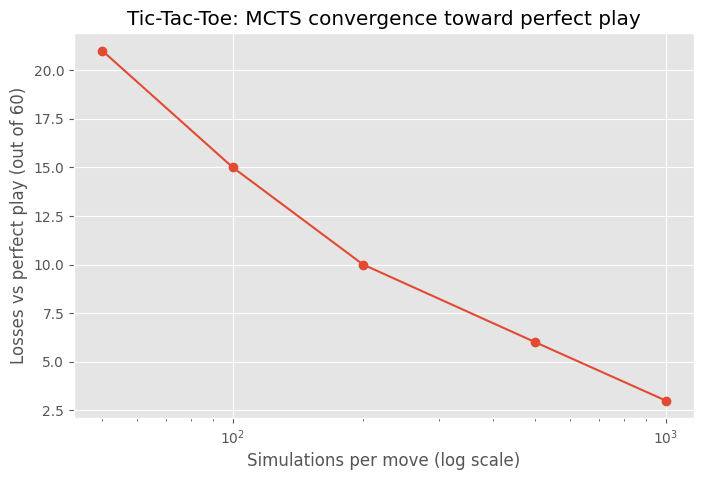

In [ ]:
if RETRAIN:
    convergence_sims = [50, 100, 200, 500, 1000]
    convergence_losses = []
    random.seed(SEED)
    for sims in convergence_sims:
        wins, losses, draws = two_sided_stats(TicTacToe, mcts_player(sims), minimax_player, 30)
        convergence_losses.append(losses)
        print(f"sims={sims}: losses vs perfect play {losses}/60")
    with open("ttt_convergence.pkl", "wb") as f:
        pickle.dump((convergence_sims, convergence_losses), f)
else:
    with open("ttt_convergence.pkl", "rb") as f:
        convergence_sims, convergence_losses = pickle.load(f)

plt.figure(figsize=(8, 5))
plt.plot(convergence_sims, convergence_losses, marker="o")
plt.xscale("log")
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Losses vs perfect play (out of 60)")
plt.title("Tic-Tac-Toe: MCTS convergence toward perfect play")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: העקומה יורדת בחדות עם התקציב — 21 הפסדים ב-50 סימולציות, 10 ב-200, בודדים ב-500-1000. ההתנהגות התאורטית של MCTS: עם מספיק סימולציות אומדני העץ מתכנסים ל-minimax. הגרף גם מראה את מחיר החישוב העולה — המניע לשלב 2: איכות גבוהה בתקציב קטן, בעזרת רשת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אחוז מהלכים אופטימליים: לכל תקציב סימולציות, יחס המהלכים שנמצאים ברשימת המהלכים האופטימליים של minimax. מדד עדין יותר ממספר הפסדים — מהלך לא אופטימלי לא תמיד נענש. תוצאות נשמרות/נטענות (RETRAIN).</p>
</div>

sims=10: optimal move rate 0.81
sims=25: optimal move rate 0.88
sims=50: optimal move rate 0.91
sims=100: optimal move rate 0.96
sims=200: optimal move rate 0.93


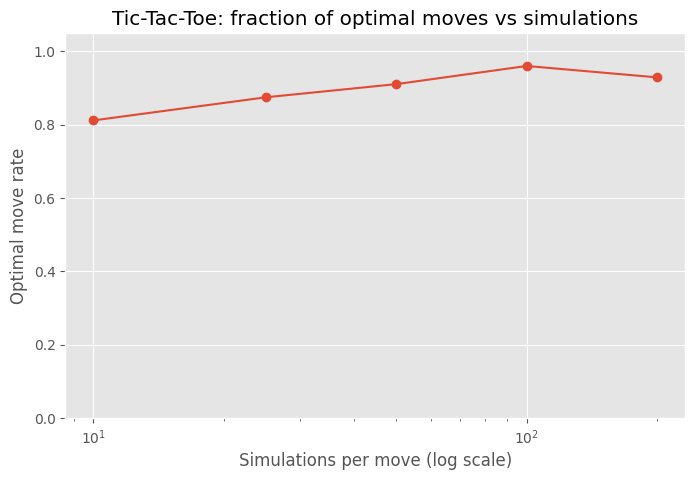

In [ ]:
if RETRAIN:
    rate_sims = [10, 25, 50, 100, 200]
    optimal_rates = []
    random.seed(SEED)
    for sims in rate_sims:
        rate = optimal_move_rate(mcts_player(sims), 30, random_player)
        optimal_rates.append(rate)
        print(f"sims={sims}: optimal move rate {rate:.2f}")
    with open("ttt_optimal_rates.pkl", "wb") as f:
        pickle.dump((rate_sims, optimal_rates), f)
else:
    with open("ttt_optimal_rates.pkl", "rb") as f:
        rate_sims, optimal_rates = pickle.load(f)

plt.figure(figsize=(8, 5))
plt.plot(rate_sims, optimal_rates, marker="o")
plt.xscale("log")
plt.ylim(0, 1.05)
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Optimal move rate")
plt.title("Tic-Tac-Toe: fraction of optimal moves vs simulations")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: האחוז עולה עם התקציב ומתייצב סביב 90-96%, עם תנודתיות דגימה קטנה. יחד עם גרף ההפסדים — תמונה עקבית: החיפוש משתפר בחלקות עם החישוב. איקס עיגול מאומת; אפשר לעבור בביטחון לסביבה המרכזית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>טורניר בארבע בשורה: MCTS בתקציב ברירת המחדל מול אקראי וחמדן, הערכה דו-צדדית. אין כאן מושלם — שני הבסיס הם קו המדידה.</p>
</div>

In [ ]:
random.seed(SEED)
c4_tournament = {}
agent = mcts_player(N_SIMULATIONS)
for opponent, name in ((random_player, "random"), (greedy_player, "greedy")):
    start = time.time()
    wins, losses, draws = two_sided_stats(ConnectFour, agent, opponent, VALIDATION_GAMES)
    total = 2 * VALIDATION_GAMES
    c4_tournament[name] = (wins / total, losses / total, draws / total)
    print(f"mcts({N_SIMULATIONS}) vs {name}: win {wins/total:.2f}  lose {losses/total:.2f}  "
          f"draw {draws/total:.2f}  time {time.time() - start:.0f}s")

mcts(200) vs random: win 0.95  lose 0.00  draw 0.05  time 10s
mcts(200) vs greedy: win 0.83  lose 0.01  draw 0.16  time 11s


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: גובר בבירור על שניהם, הפסדים כמעט אפסיים גם מול חמדן. תיקו גבוה יחסית מול חמדן (16%) — שוב מעיד שהלוח המוקטן נוטה לתיקו במשחק סביר, כמו בבדיקת השפיות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אבלציה — מספר סימולציות בארבע בשורה: לכל ערך ב-SIM_COUNTS, שיעורי ניצחון/הפסד מול חמדן על 5 זרעים בנפרד (הערכה דו-צדדית). הגרף מציג ממוצע±std, כנדרש בהנחיות. הניסוי הכבד ביותר בשלב 1; תוצאות נשמרות/נטענות (RETRAIN).</p>
</div>

sims=10: win 0.35 +- 0.03  lose 0.33 +- 0.05
sims=25: win 0.59 +- 0.05  lose 0.13 +- 0.05
sims=50: win 0.75 +- 0.02  lose 0.05 +- 0.03
sims=100: win 0.74 +- 0.05  lose 0.03 +- 0.01
sims=200: win 0.84 +- 0.02  lose 0.01 +- 0.01
sims=400: win 0.86 +- 0.05  lose 0.01 +- 0.02


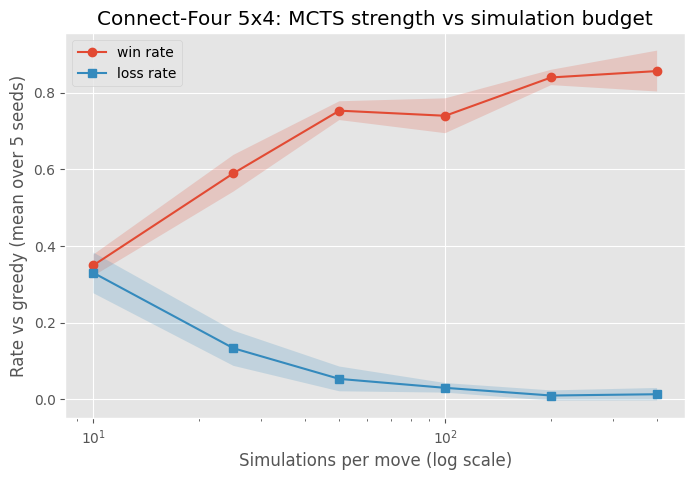

In [ ]:
if RETRAIN:
    ablation = {"win": [], "lose": []}
    for sims in SIM_COUNTS:
        win_rates, lose_rates = [], []
        for seed in SEEDS:
            random.seed(seed)
            wins, losses, draws = two_sided_stats(ConnectFour, mcts_player(sims), greedy_player, ABLATION_GAMES)
            total = 2 * ABLATION_GAMES
            win_rates.append(wins / total)
            lose_rates.append(losses / total)
        ablation["win"].append(win_rates)
        ablation["lose"].append(lose_rates)
        print(f"sims={sims}: win {np.mean(win_rates):.2f} +- {np.std(win_rates):.2f}  "
              f"lose {np.mean(lose_rates):.2f} +- {np.std(lose_rates):.2f}")
    with open("c4_ablation.pkl", "wb") as f:
        pickle.dump(ablation, f)
else:
    with open("c4_ablation.pkl", "rb") as f:
        ablation = pickle.load(f)

win_mean = np.array([np.mean(r) for r in ablation["win"]])
win_std = np.array([np.std(r) for r in ablation["win"]])
lose_mean = np.array([np.mean(r) for r in ablation["lose"]])
lose_std = np.array([np.std(r) for r in ablation["lose"]])

plt.figure(figsize=(8, 5))
plt.plot(SIM_COUNTS, win_mean, marker="o", label="win rate")
plt.fill_between(SIM_COUNTS, win_mean - win_std, win_mean + win_std, alpha=0.2)
plt.plot(SIM_COUNTS, lose_mean, marker="s", label="loss rate")
plt.fill_between(SIM_COUNTS, lose_mean - lose_std, lose_mean + lose_std, alpha=0.2)
plt.xscale("log")
plt.xlabel("Simulations per move (log scale)")
plt.ylabel("Rate vs greedy (mean over 5 seeds)")
plt.title("Connect-Four 5x4: MCTS strength vs simulation budget")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: בתקציב זעיר (10) האלגוריתם קרוב לשוויון עם החמדן — לא מספיק מידע לזהות איומים. בין 10-50 קפיצת המדרגה: הפסדים צונחים כמעט לאפס. מעל כ-100 פלטו — תוספת חישוב כמעט לא מתורגמת לניצחונות (חלק מהמשחקים מסתיימים בתיקו). רצועות std צרות — יציב בין זרעים. לקראת שלב 2: רוב הרווח מושג בתקציב קטן; האם רשת דוחפת את התקרה בלי להגדיל תקציב?</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אבלציה שנייה — עומק ה-rollout: הסימולציה נקטעת לאחר מספר מהלכים נתון; אם המשחק לא הוכרע עד אז, התוצאה נזקפת כתיקו (ההנחה הניטרלית הסבירה). מספר הסימולציות מקובע ל-100 כדי לבודד את השפעת העומק בלבד.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>rollout_limited — כמו rollout, אך עוצר אחרי max_depth מהלכים: אם הסתיים קודם — התוצאה האמיתית; אם נקטע קודם — 0 (תיקו).</p>
</div>

In [ ]:
def rollout_limited(game, max_depth):
    g = game.clone()
    depth = 0
    while g.winner() is None and depth < max_depth:
        g.play(random.choice(g.legal_moves()))
        depth += 1
    winner = g.winner()
    return 0 if winner is None else winner

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_search_depth — כמו mcts_search, עם rollout_limited במקום rollout.</p>
</div>

In [ ]:
def mcts_search_depth(game, n_simulations, max_depth, c=UCT_C):
    root = MCTSNode(game.clone())
    for _ in range(n_simulations):
        node = select(root, c)
        if node.untried_moves:
            node = expand(node)
        winner = rollout_limited(node.game, max_depth)
        backpropagate(node, winner)
    return max(root.children, key=lambda ch: ch.visits).move

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_player_depth — אורזת את mcts_search_depth כפונקציית שחקן, כמו שאר הסוכנים.</p>
</div>

In [ ]:
def mcts_player_depth(n_simulations, max_depth, c=UCT_C):
    def player(game):
        return mcts_search_depth(game, n_simulations, max_depth, c)
    return player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אבלציה — עומק ה-rollout בארבע בשורה: לכל עומק ב-rollout_depths, שיעורי ניצחון/הפסד מול חמדן על 3 זרעים (20 משחקים דו-צדדיים כל אחד). מספר הסימולציות מקובע ל-100 לבידוד השפעת העומק בלבד. תוצאות נשמרות/נטענות (RETRAIN).</p>
</div>

depth=1: win 0.43 +- 0.07  lose 0.08 +- 0.05
depth=2: win 0.53 +- 0.06  lose 0.10 +- 0.06
depth=4: win 0.71 +- 0.02  lose 0.04 +- 0.02
depth=8: win 0.76 +- 0.02  lose 0.05 +- 0.04
depth=20: win 0.76 +- 0.03  lose 0.03 +- 0.01


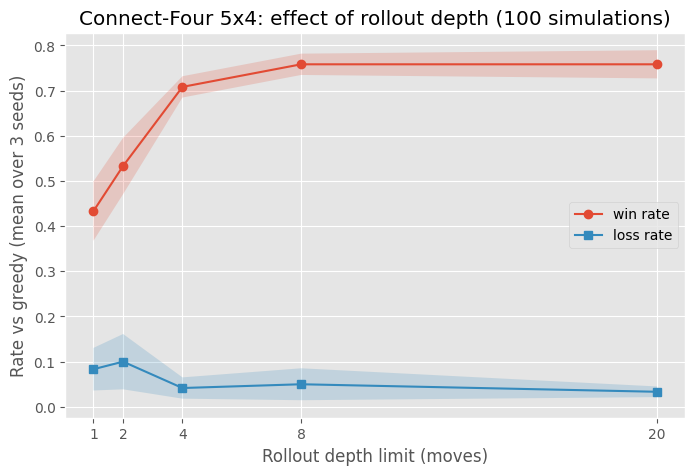

In [ ]:
if RETRAIN:
    rollout_depths = [1, 2, 4, 8, 20]
    depth_results = {"win": [], "lose": []}
    for depth in rollout_depths:
        win_rates, lose_rates = [], []
        for seed in SEEDS[:3]:
            random.seed(seed)
            wins, losses, draws = two_sided_stats(ConnectFour, mcts_player_depth(100, depth), greedy_player, 20)
            win_rates.append(wins / 40)
            lose_rates.append(losses / 40)
        depth_results["win"].append(win_rates)
        depth_results["lose"].append(lose_rates)
        print(f"depth={depth}: win {np.mean(win_rates):.2f} +- {np.std(win_rates):.2f}  "
              f"lose {np.mean(lose_rates):.2f} +- {np.std(lose_rates):.2f}")
    with open("c4_rollout_depth.pkl", "wb") as f:
        pickle.dump((rollout_depths, depth_results), f)
else:
    with open("c4_rollout_depth.pkl", "rb") as f:
        rollout_depths, depth_results = pickle.load(f)

depth_win_mean = np.array([np.mean(r) for r in depth_results["win"]])
depth_win_std = np.array([np.std(r) for r in depth_results["win"]])
depth_lose_mean = np.array([np.mean(r) for r in depth_results["lose"]])
depth_lose_std = np.array([np.std(r) for r in depth_results["lose"]])

plt.figure(figsize=(8, 5))
plt.plot(rollout_depths, depth_win_mean, marker="o", label="win rate")
plt.fill_between(rollout_depths, depth_win_mean - depth_win_std, depth_win_mean + depth_win_std, alpha=0.2)
plt.plot(rollout_depths, depth_lose_mean, marker="s", label="loss rate")
plt.fill_between(rollout_depths, depth_lose_mean - depth_lose_std, depth_lose_mean + depth_lose_std, alpha=0.2)
plt.xticks(rollout_depths)
plt.xlabel("Rollout depth limit (moves)")
plt.ylabel("Rate vs greedy (mean over 3 seeds)")
plt.title("Connect-Four 5x4: effect of rollout depth (100 simulations)")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: שיעור הניצחון עולה מ-0.43 בעומק 1 ל-0.53 בעומק 2, קופץ ל-0.71 בעומק 4, ומתייצב על כ-0.76 מעומק 8 — עומק שמכסה את רוב אורכי המשחק שנותרו מהאמצע. שתי תובנות: גם בעומק 1 הסוכן חזק מהחמדן, כי העץ עצמו מעמיק לאורך הסימולציות והקטיעה חלה רק על החלק האקראי שמעבר לחזית; וקטיעה מוקדמת מדללת את אות הלמידה (משחקים לא מוכרעים = תיקו לא אינפורמטיבי). הקצה השני של הסקאלה הוא שלב 2: עומק אפס, כשהעלה מוערך על ידי רשת נלמדת במקום rollout.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת המדיניות של החיפוש: התפלגות הביקורים בשורש היא המדיניות של MCTS. הגרף מציג את מספר הביקורים שכל עמודה מקבלת במהלך הפתיחה של ארבע בשורה, ואחריו מודפס משחק הדגמה מלא של האלגוריתם נגד השחקן החמדן.</p>
</div>

col 0: 183
col 1: 283
col 2: 180
col 3: 200
col 4: 154


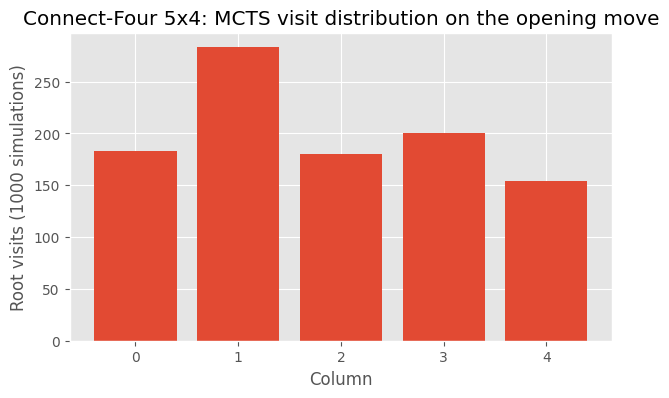

In [ ]:
random.seed(SEED)
visits = mcts_root_visits(ConnectFour(), 1000)
columns = sorted(visits.keys())
counts = [visits[c] for c in columns]
for c, v in zip(columns, counts):
    print(f"col {c}: {v}")

plt.figure(figsize=(7, 4))
plt.bar([str(c) for c in columns], counts)
plt.xlabel("Column")
plt.ylabel("Root visits (1000 simulations)")
plt.title("Connect-Four 5x4: MCTS visit distribution on the opening move")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: התפלגות הביקורים לא אחידה אך מתונה — עמודה 1 מובילה (283), עמודה 4 הכי פחות (154). לוח מוקטן שנוטה לתיקו, ולכן אות הפתיחה חלש. במשחק ההדגמה נראה היתרון בפועל: איומים מרובים במקביל, והחמדן — חוסם רק אחד — נופל למלכודת. שלב 1 הושלם: מימוש מאומת, עקומות התכנסות ואבלציה. שלב 2: להחליף סימולציות אקראיות בידע נלמד.</p>
</div>

In [ ]:
random.seed(SEED)
result = render_move_sequence(ConnectFour(), mcts_player(N_SIMULATIONS), greedy_player, boards_per_row=5)
print("result:", result)

     . . . . .          . . . . .          . . . . .          . . . . .          . . . . .     
     . . . . .          . . . . .          . . . . .          . . . . .          . . . X .     
 1)  . . . . .      2)  . . . . .      3)  . . . X .      4)  . . . X .      5)  . . . X .     
     . . . X .          . . . X O          . . . X O          . . O X O          . . O X O     

     . . . O .          . . . O .          . . . O .          . . . O .          . . . O .     
     . . . X .          . . . X .          . . . X .          . . . X .          . . . X .     
 6)  . . . X .      7)  . . . X .      8)  . . . X O      9)  . . X X O     10)  . O X X O     
     . . O X O          . X O X O          . X O X O          . X O X O          . X O X O     

     . . . O .          . . O O .          . . O O .          . . O O O          . . O O O     
     . . X X .          . . X X .          . . X X X          . . X X X          . X X X X     
11)  . O X X O     12)  . O X X O     

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח משחק ההדגמה: המלכודת הכפולה מתגלה במפורש לקראת מהלך 14 — ל-X יש בו-זמנית שני מהלכים מנצחים: עמודה 1 משלימה רצף אופקי, ועמודה 4 משלימה רצף אלכסוני, ושתי השלשות חולקות אבן משותפת. greedy_player מזהה נכון ששתי העמודות חוסמות ניצחון-יריב (winning_moves מחזירה [1, 4]), אך אין ביניהן דירוג — הבחירה אקראית, ובריצה זו נחתה על עמודה 4 וחסמה רק את האלכסון. במהלך 15 X ממש את האיום השני שנותר פתוח, עמודה 1, ומנצח ברצף אופקי. זו בדיוק העיוורון שתואר בהגדרת greedy_player: תגובה למהלך-קדימה אחד, בלי יכולת לדרג בין איומים מרובים בו-זמנית — בדיוק מה שחיפוש-קדימה מנצל.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלב 2 — רשת policy ו-value ולמידה ממשחק עצמי:</p>
<p>בעקבות AlphaZero: רשת עם שני ראשים מחזירה מדיניות (התפלגות מהלכים) וערך (הערכת תוצאה). הערך מחליף rollout בהערכת עלים; המדיניות מכוונת את החיפוש דרך PUCT.</p>
<p>הלולאה: משחק עצמי עם רעש דיריכלה ודגימה לפי ביקורים בפתיחה; שמירת (מצב, ביקורים כיעד מדיניות, תוצאה כיעד ערך); אימון על מאגר מתגלגל (cross entropy+MSE); הרשת המעודכנת משחקת הלאה. במונחי הקורס: policy iteration מפוקח לחלוטין — החיפוש מייצר יעדים משופרים, האימון הוא צעד שיפור מדיניות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>action_size — גודל מרחב הפעולות: 9 באיקס עיגול, מספר העמודות בארבע בשורה. קובע את ממד ראש המדיניות ואורך יעד המדיניות.</p>
</div>

In [ ]:
def action_size(game):
    if isinstance(game, TicTacToe):
        return 9
    return game.cols

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>encode_state — הלוח מוכפל בזהות השחקן הנוכחי, כך ש-1 תמיד "שלי" ומינוס 1 "יריב" — חוסך מהרשת ללמוד את המשחק פעמיים.</p>
</div>

In [ ]:
def encode_state(game):
    board = np.array(game.board, dtype=np.float32).flatten()
    return board * game.player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>PolicyValueNet — רשת קטנה עם גוף משותף ושני ראשים:</p>
<ul>
<li>init — שתי שכבות לינאריות ברוחב HIDDEN_SIZE עם ReLU; ראש מדיניות (גודל מרחב הפעולות), ראש ערך (1)</li>
<li>forward — לוגיטים ללא softmax (מופעל בהמשך אחרי מיסוך מהלכים לא חוקיים); ערך עם tanh לטווח [-1,1]</li>
</ul>
</div>

In [ ]:
class PolicyValueNet(nn.Module):
    def __init__(self, input_size, n_moves, hidden=HIDDEN_SIZE):
        super().__init__()
        self.shared = nn.Sequential(nn.Linear(input_size, hidden), nn.ReLU(),
                                    nn.Linear(hidden, hidden), nn.ReLU())
        self.policy_head = nn.Linear(hidden, n_moves)
        self.value_head = nn.Linear(hidden, 1)

    def forward(self, x):
        h = self.shared(x)
        return self.policy_head(h), torch.tanh(self.value_head(h))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>net_evaluate — הרשת על מצב בודד, בלי גרדיאנטים. לוגיטים של מהלכים לא חוקיים נדרסים למינוס אינסוף לפני softmax, כך שההסתברות מתפלגת רק על החוקיים. מוחזרים priors וערך המצב.</p>
</div>

In [ ]:
def net_evaluate(net, game):
    x = torch.tensor(encode_state(game), device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        logits, value = net(x)
    logits = logits[0]
    legal = game.legal_moves()
    masked = torch.full_like(logits, float("-inf"))
    masked[legal] = logits[legal]
    priors = F.softmax(masked, dim=0)
    return priors, value.item()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>NetNode — כמו MCTSNode, עם שדה prior (הסתברות הרשת למהלך שהוביל לצומת), בלי מהלכים שטרם נוסו — כאן צומת מורחב בבת אחת עם כל ילדיו בביקור הראשון.</p>
</div>

In [ ]:
class NetNode:
    def __init__(self, game, parent=None, move=None, prior=0.0):
        self.game = game
        self.parent = parent
        self.move = move
        self.prior = prior
        self.children = []
        self.visits = 0
        self.score = 0.0

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>puct_value — ניצול: ניקוד ממוצע (0.5 אם טרם בוקר); חקר: גדל עם prior ושורש ביקורי ההורה, דועך עם ביקורי הילד. ההבדל מ-UCT: הרשת מכוונת את החקר למהלכים מבטיחים עוד לפני ביקור ראשון.</p>
</div>

In [ ]:
def puct_value(child, parent_visits, c):
    q = child.score / child.visits if child.visits > 0 else 0.5
    u = c * child.prior * math.sqrt(parent_visits + 1) / (1 + child.visits)
    return q + u

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>select_net — יורד מהשורש לפי PUCT מקסימלי, עד עלה (טרם הורחב או מצב סופי).</p>
</div>

In [ ]:
def select_net(node, c):
    while node.children:
        node = max(node.children, key=lambda ch: puct_value(ch, node.visits, c))
    return node

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>expand_net — מצב סופי: מוחזרת תוצאתו כערך מדויק. אחרת: הרשת מוערכת פעם אחת, כל הילדים נוצרים בבת אחת עם ה-prior שלהם, ומוחזר ערך הרשת. כאן הרשת מחליפה את rollout של שלב 1 — במקום משחק אקראי שלם, שואלים את הרשת.</p>
</div>

In [ ]:
def expand_net(node, net):
    winner = node.game.winner()
    if winner is not None:
        if winner == 0:
            return 0.0
        return 1.0 if winner == node.game.player else -1.0
    priors, value = net_evaluate(net, node.game)
    for move in node.game.legal_moves():
        g = node.game.clone()
        g.play(move)
        node.children.append(NetNode(g, parent=node, move=move, prior=priors[move].item()))
    return value

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>backpropagate_value — כמו backpropagate, ממפה ערך [-1,1] לניקוד [0,1] מנקודת מבט השחקן שביצע את המהלך.</p>
</div>

In [ ]:
def backpropagate_value(node, value, value_player):
    while node is not None:
        node.visits += 1
        mover = -node.game.player
        if mover == value_player:
            node.score += (value + 1) / 2
        else:
            node.score += (1 - value) / 2
        node = node.parent

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>add_root_noise — משחק עצמי בלבד (כבוי בהערכה): ה-prior של כל ילד שורש משוקלל עם דגימת דיריכלה. בלי זה, רשת בטוחה בעצמה חוזרת על אותם משחקים והאימון נתקע; הרעש מכריח ביקור גם במהלכים שהרשת מזלזלת בהם.</p>
</div>

In [ ]:
def add_root_noise(root):
    noise = np.random.dirichlet([DIRICHLET_ALPHA] * len(root.children))
    for child, n in zip(root.children, noise):
        child.prior = (1 - DIRICHLET_EPS) * child.prior + DIRICHLET_EPS * float(n)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_net_search — השורש מורחב ומוערך, רעש מוזרק אם משחק עצמי, ואז לולאת בחירה-הרחבה-עדכון. בטמפרטורה 0 מוחזר המהלך המבוקר ביותר; בטמפרטורה חיובית נדגם מהתפלגות הביקורים (גיוון בפתיחות). מחזירה גם מהלכים+ביקורים, לבניית יעד המדיניות באימון.</p>
</div>

In [ ]:
def mcts_net_search(game, net, n_simulations, c=PUCT_C, temperature=0.0, root_noise=False):
    root = NetNode(game.clone())
    root_value = expand_net(root, net)
    backpropagate_value(root, root_value, root.game.player)
    if root_noise and root.children:
        add_root_noise(root)
    for _ in range(n_simulations):
        node = select_net(root, c)
        value = expand_net(node, net)
        backpropagate_value(node, value, node.game.player)
    moves = [child.move for child in root.children]
    visits = np.array([child.visits for child in root.children], dtype=np.float64)
    if temperature == 0:
        move = moves[int(np.argmax(visits))]
    else:
        probs = visits ** (1.0 / temperature)
        probs = probs / probs.sum()
        move = moves[int(np.random.choice(len(moves), p=probs))]
    return move, moves, visits

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>mcts_net_player — אורזת את mcts_net_search כפונקציית שחקן, טמפרטורה 0 ובלי רעש — משחק תחרותי נקי.</p>
</div>

In [ ]:
def mcts_net_player(net, n_simulations=SELFPLAY_SIMS, c=PUCT_C):
    def player(game):
        move, _, _ = mcts_net_search(game, net, n_simulations, c)
        return move
    return player

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>self_play_game — משחק שלם נגד עצמו: לכל עמדה נשמר (מצב, התפלגות ביקורים מנורמלת כיעד מדיניות, שחקן שתורו). בסוף המשחק כל דוגמה מקבלת z לפי התוצאה מנקודת מבט השחקן שם: 1/מינוס 1/0. שני המהלכים הראשונים בטמפרטורה 1 לגיוון פתיחות, אחר כך 0.</p>
</div>

In [ ]:
def self_play_game(game_class, net, n_simulations=SELFPLAY_SIMS):
    game = game_class()
    states, policies, players = [], [], []
    move_count = 0
    while game.winner() is None:
        temperature = 1.0 if move_count < TEMPERATURE_MOVES else 0.0
        move, moves, visits = mcts_net_search(game, net, n_simulations, PUCT_C, temperature, root_noise=True)
        pi = np.zeros(action_size(game), dtype=np.float32)
        pi[moves] = (visits / visits.sum()).astype(np.float32)
        states.append(encode_state(game))
        policies.append(pi)
        players.append(game.player)
        game.play(move)
        move_count += 1
    winner = game.winner()
    examples = []
    for state, pi, player in zip(states, policies, players):
        z = 0.0 if winner == 0 else (1.0 if winner == player else -1.0)
        examples.append((state, pi, z))
    return examples

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>train_network — למידה מפוקחת: הפסד = cross entropy (ביקורים מול ראש מדיניות) + MSE (תוצאה מול ראש ערך). כמה epochs על מיני-batches עם Adam, מוחזר ההפסד הממוצע.</p>
</div>

In [ ]:
def train_network(net, examples):
    optimizer = torch.optim.Adam(net.parameters(), lr=LEARNING_RATE)
    states = torch.tensor(np.array([e[0] for e in examples]), device=DEVICE)
    policies = torch.tensor(np.array([e[1] for e in examples]), device=DEVICE)
    values = torch.tensor(np.array([e[2] for e in examples], dtype=np.float32), device=DEVICE).unsqueeze(1)
    losses = []
    for _ in range(TRAIN_EPOCHS):
        perm = torch.randperm(len(examples))
        for i in range(0, len(examples), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            logits, value = net(states[idx])
            policy_loss = -(policies[idx] * F.log_softmax(logits, dim=1)).sum(dim=1).mean()
            value_loss = F.mse_loss(value, values[idx])
            loss = policy_loss + value_loss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    return float(np.mean(losses))

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>alphazero_training — הלולאה המלאה: בכל סבב נאספות דוגמאות ממשחק עצמי למאגר מתגלגל (עד BUFFER_SIZE), הרשת מתאמנת עליו, ונמדדת בהערכה דו-צדדית מול יריב ייחוס. המאגר המתגלגל מייצב את האימון — הרשת רואה גם סבבים קודמים, לא רק את האחרון. מחזירה את הרשת המאומנת והיסטוריית הפסד/תוצאות לעקומות הלמידה.</p>
</div>

In [ ]:
def alphazero_training(game_class, input_size, opponent,
                       iterations=TRAIN_ITERATIONS,
                       games_per_iteration=GAMES_PER_ITERATION,
                       n_simulations=SELFPLAY_SIMS,
                       eval_games=EVAL_GAMES_PER_ITERATION):
    net = PolicyValueNet(input_size, action_size(game_class())).to(DEVICE)
    buffer = []
    history = {"loss": [], "win": [], "lose": [], "draw": []}
    for iteration in range(iterations):
        for _ in range(games_per_iteration):
            buffer.extend(self_play_game(game_class, net, n_simulations))
        buffer = buffer[-BUFFER_SIZE:]
        mean_loss = train_network(net, buffer)
        agent = mcts_net_player(net, n_simulations)
        wins, losses, draws = two_sided_stats(game_class, agent, opponent, eval_games)
        total = 2 * eval_games
        history["loss"].append(mean_loss)
        history["win"].append(wins / total)
        history["lose"].append(losses / total)
        history["draw"].append(draws / total)
        print(f"iteration {iteration}: loss={mean_loss:.3f} "
              f"win={wins/total:.2f} lose={losses/total:.2f} draw={draws/total:.2f}")
    return net, history

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניסויי שלב 2 — אימון על איקס עיגול:</p>
<p>20 סבבים של 30 משחקים עצמיים, הערכה מול חמדן אחרי כל סבב. לולאה בריאה = הפסד יורד ושיעור הפסדים מול חמדן מתאפס. נשמר לקבצים.</p>
</div>

iteration 0: loss=2.728 win=0.37 lose=0.10 draw=0.53
iteration 1: loss=2.692 win=0.30 lose=0.07 draw=0.63
iteration 2: loss=2.515 win=0.40 lose=0.20 draw=0.40
iteration 3: loss=2.416 win=0.27 lose=0.17 draw=0.57
iteration 4: loss=2.321 win=0.20 lose=0.20 draw=0.60
iteration 5: loss=2.203 win=0.27 lose=0.10 draw=0.63
iteration 6: loss=2.104 win=0.27 lose=0.13 draw=0.60
iteration 7: loss=1.982 win=0.27 lose=0.10 draw=0.63
iteration 8: loss=1.860 win=0.43 lose=0.03 draw=0.53
iteration 9: loss=1.762 win=0.50 lose=0.00 draw=0.50
iteration 10: loss=1.672 win=0.60 lose=0.00 draw=0.40
iteration 11: loss=1.585 win=0.50 lose=0.07 draw=0.43
iteration 12: loss=1.559 win=0.47 lose=0.07 draw=0.47
iteration 13: loss=1.519 win=0.67 lose=0.00 draw=0.33
iteration 14: loss=1.487 win=0.53 lose=0.00 draw=0.47
iteration 15: loss=1.464 win=0.47 lose=0.07 draw=0.47
iteration 16: loss=1.425 win=0.50 lose=0.03 draw=0.47
iteration 17: loss=1.360 win=0.53 lose=0.00 draw=0.47
iteration 18: loss=1.313 win=0.43 lose

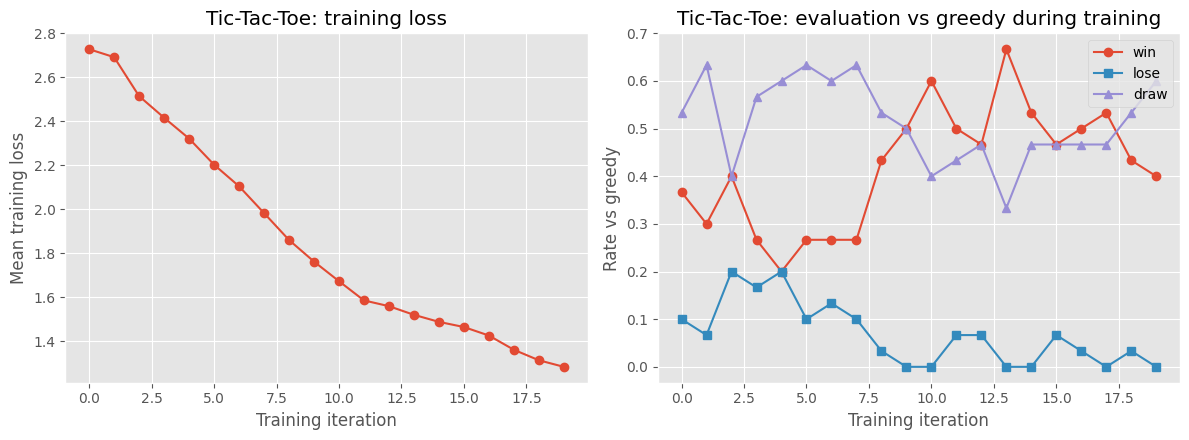

In [ ]:
if RETRAIN:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    start = time.time()
    ttt_net, ttt_history = alphazero_training(TicTacToe, 9, greedy_player, iterations=20)
    print(f"training time: {time.time() - start:.0f}s")
    torch.save(ttt_net.state_dict(), "ttt_net.pt")
    with open("ttt_history.pkl", "wb") as f:
        pickle.dump(ttt_history, f)
else:
    ttt_net = PolicyValueNet(9, 9).to(DEVICE)
    ttt_net.load_state_dict(torch.load("ttt_net.pt"))
    with open("ttt_history.pkl", "rb") as f:
        ttt_history = pickle.load(f)

iterations = range(len(ttt_history["loss"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(iterations, ttt_history["loss"], marker="o")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("Mean training loss")
axes[0].set_title("Tic-Tac-Toe: training loss")
axes[1].plot(iterations, ttt_history["win"], marker="o", label="win")
axes[1].plot(iterations, ttt_history["lose"], marker="s", label="lose")
axes[1].plot(iterations, ttt_history["draw"], marker="^", label="draw")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("Rate vs greedy")
axes[1].set_title("Tic-Tac-Toe: evaluation vs greedy during training")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: ההפסד יורד עקבית — הרשת לומדת לחקות את תוצרי החיפוש. אין ברך חדה כמו באימון על דאטה קבוע, וזה מובנה ולא תקלה: היעדים נעים (הדאטה נוצר מחדש כל סבב על ידי הרשת המשתפרת), ויש רצפת הפסד — יעד המדיניות אינו one-hot, ותוצאת משחק אקראית חלקית. הברך מופיעה דווקא בעקומת הביצועים: הפסדים מול חמדן דועכים כמעט לאפס, וניצחון/תיקו מתחלקים ביניהם — תקרה צפויה כי חמדן שמתגונן היטב מגיע לתיקו. המבחן האמיתי מול השחקן המושלם, בתא הבא.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבחני הזהב באיקס עיגול: הפסדים מול minimax בשני תקציבים, אחוז מהלכים אופטימליים, וקרב ישיר מול MCTS טהור באותו תקציב. המבחנים שמכריעים אם הרשת באמת משפרת את החיפוש.</p>
</div>

In [ ]:
random.seed(SEED)
for sims in (50, 200):
    wins, losses, draws = two_sided_stats(TicTacToe, mcts_net_player(ttt_net, sims), minimax_player, 30)
    print(f"net-mcts({sims}) vs perfect play: wins {wins}/60  losses {losses}/60  draws {draws}/60")

rate_net = optimal_move_rate(mcts_net_player(ttt_net, 50), 30, random_player)
rate_pure = optimal_move_rate(mcts_player(50), 30, random_player)
print(f"optimal move rate at 50 simulations: net {rate_net:.2f}  pure {rate_pure:.2f}")

wins, losses, draws = two_sided_stats(TicTacToe, mcts_net_player(ttt_net, 50), mcts_player(50), 20)
print(f"net-mcts(50) vs pure mcts(50): wins {wins}/40  losses {losses}/40  draws {draws}/40")

net-mcts(50) vs perfect play: wins 0/60  losses 5/60  draws 55/60
net-mcts(200) vs perfect play: wins 0/60  losses 2/60  draws 58/60
optimal move rate at 50 simulations: net 1.00  pure 0.88
net-mcts(50) vs pure mcts(50): wins 18/40  losses 0/40  draws 22/40


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: הרשת יורדת להפסדים בודדים עד אפס מול מושלם — 5/60 ב-50 סימולציות, 2/60 ב-200 — לעומת 10-21 הפסדים של החיפוש הטהור בתקציבים דומים. אחוז המהלכים האופטימליים ב-50 סימולציות: רשת 1.00, טהור 0.88. בקרב הישיר באותו תקציב: 18 נצחונות מול 0 הפסדים לרשת. מסקנה: הידע הנלמד שווה הרבה סימולציות. נשאר לבדוק בסביבה הגדולה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>כיול ראש הערך מול האמת: ערכי האמת מ-minimax (הערך המוחלט כפול זהות השחקן), מולם ערך הרשת. נבדק גם אם המהלך המוביל במדיניות הגולמית אופטימלי. מודפסים RMSE וקליעת המדיניות; הגרף מציג פיזור תחזיות לפי שלוש קבוצות אמת: הפסד, תיקו, ניצחון.</p>
</div>

In [ ]:
minimax_value(TicTacToe())
calibration = {-1: [], 0: [], 1: []}
policy_hits = 0
policy_total = 0
squared_errors = []
for board, player in MINIMAX_CACHE:
    g = TicTacToe()
    g.board = list(board)
    g.player = player
    if g.winner() is not None:
        continue
    true_value = player * MINIMAX_CACHE[(board, player)]
    priors, net_value = net_evaluate(ttt_net, g)
    calibration[true_value].append(net_value)
    squared_errors.append((net_value - true_value) ** 2)
    if int(torch.argmax(priors).item()) in optimal_moves(g):
        policy_hits += 1
    policy_total += 1

value_rmse = float(np.sqrt(np.mean(squared_errors)))
print(f"non-terminal states evaluated: {policy_total}")
print(f"value head RMSE vs minimax: {value_rmse:.3f}")
print(f"raw policy top move optimal: {policy_hits / policy_total:.2f}")

non-terminal states evaluated: 4520
value head RMSE vs minimax: 0.697
raw policy top move optimal: 0.86


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הרשת נבדקה על 4,520 מצבים לא-סופיים. RMSE של ראש הערך מול minimax: 0.697 — גבוה יחסית לטווח [-1,1]. אחוז קליעה של המהלך המוביל במדיניות הגולמית: 0.86. הגרף הבא מפרק את התחזיות לפי קטגוריית האמת.</p>
</div>

              n states      mean       std    median
-1 (loss)          632    -0.248     0.529    -0.326
0 (draw)          1052     0.061     0.367     0.106
+1 (win)          2836     0.428     0.456     0.538


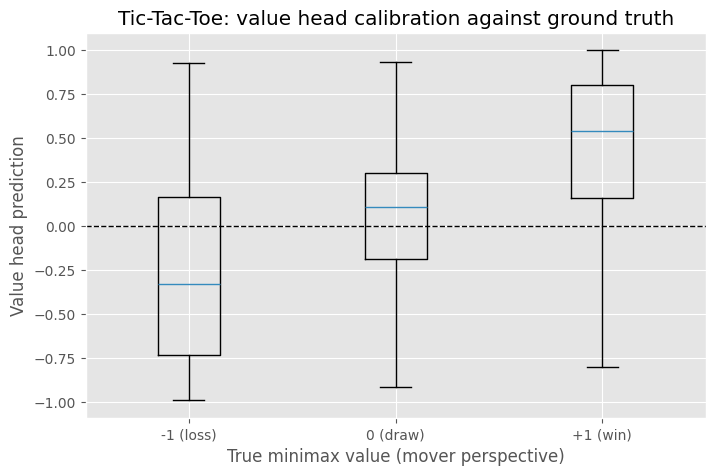

In [ ]:
labels = ["-1 (loss)", "0 (draw)", "+1 (win)"]
keys = [-1, 0, 1]

print(f"{'':<12}{'n states':>10}{'mean':>10}{'std':>10}{'median':>10}")
for label, k in zip(labels, keys):
    vals = calibration[k]
    print(f"{label:<12}{len(vals):>10}{np.mean(vals):>10.3f}{np.std(vals):>10.3f}{np.median(vals):>10.3f}")

groups = [calibration[-1], calibration[0], calibration[1]]
plt.figure(figsize=(8, 5))
plt.boxplot(groups, showfliers=False)
plt.xticks([1, 2, 3], ["-1 (loss)", "0 (draw)", "+1 (win)"])
plt.axhline(0, linestyle="--", linewidth=1, color="black")
plt.xlabel("True minimax value (mover perspective)")
plt.ylabel("Value head prediction")
plt.title("Tic-Tac-Toe: value head calibration against ground truth")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: שלוש הקבוצות מסודרות נכון — אבודים שליליים, מנצחים חיוביים, תיקו סביב אפס — אך הפיזור רחב וה-RMSE גבוה בהרבה מהדיוק שהרשת מפגינה בתוך החיפוש. זו תזת הפרויקט בגרף אחד: הרשת לבדה מעריך גס, אך מספיקה כהכוונה כדי שהחיפוש יגיע למשחק כמעט מושלם. ההסבר: הרשת אומנה רק על מצבים ממשחק עצמי של סוכן חזק, בעוד רוב מרחב המצבים נוצר דווקא מטעויות שלא קורות שם — מחוץ להתפלגות האימון. זו הסיבה שהחיפוש נשאר הכרחי ולא מוחלף ברשת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>אימון על ארבע בשורה: אותה לולאה בדיוק, הפעם על הסביבה המרכזית — 15 סבבים של 30 משחקים עצמיים עם 60 סימולציות למהלך, הערכה מול החמדן אחרי כל סבב.</p>
</div>

iteration 0: loss=1.937 win=0.83 lose=0.03 draw=0.13
iteration 1: loss=1.887 win=0.57 lose=0.07 draw=0.37
iteration 2: loss=1.891 win=0.53 lose=0.13 draw=0.33
iteration 3: loss=1.903 win=0.77 lose=0.00 draw=0.23
iteration 4: loss=1.854 win=0.67 lose=0.07 draw=0.27
iteration 5: loss=1.819 win=0.63 lose=0.07 draw=0.30
iteration 6: loss=1.779 win=0.63 lose=0.10 draw=0.27
iteration 7: loss=1.709 win=0.60 lose=0.03 draw=0.37
iteration 8: loss=1.684 win=0.57 lose=0.10 draw=0.33
iteration 9: loss=1.630 win=0.67 lose=0.03 draw=0.30
iteration 10: loss=1.623 win=0.60 lose=0.07 draw=0.33
iteration 11: loss=1.629 win=0.70 lose=0.03 draw=0.27
iteration 12: loss=1.587 win=0.73 lose=0.03 draw=0.23
iteration 13: loss=1.522 win=0.77 lose=0.03 draw=0.20
iteration 14: loss=1.478 win=0.67 lose=0.00 draw=0.33
training time: 369s


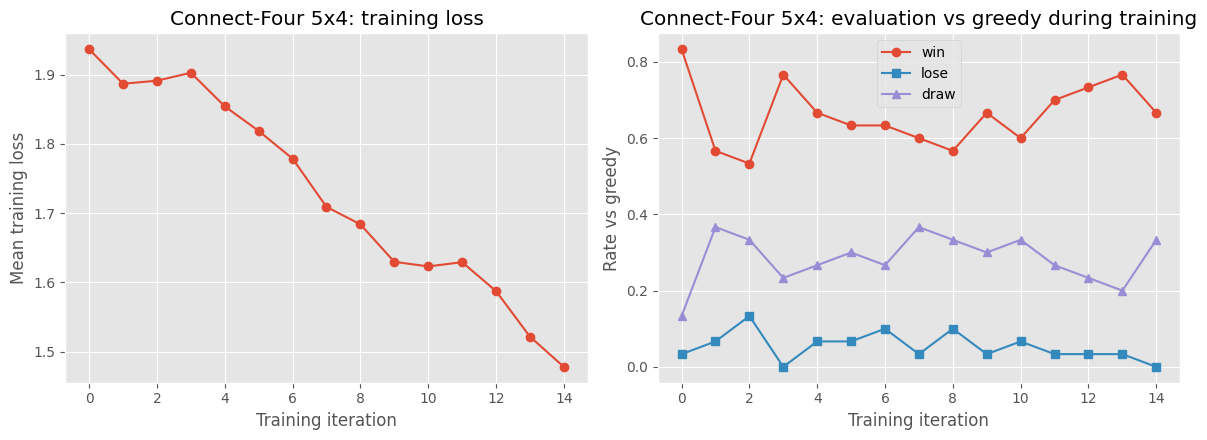

In [ ]:
if RETRAIN:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    start = time.time()
    c4_net, c4_history = alphazero_training(ConnectFour, C4_ROWS * C4_COLS, greedy_player)
    print(f"training time: {time.time() - start:.0f}s")
    torch.save(c4_net.state_dict(), "c4_net.pt")
    with open("c4_history.pkl", "wb") as f:
        pickle.dump(c4_history, f)
else:
    c4_net = PolicyValueNet(C4_ROWS * C4_COLS, C4_COLS).to(DEVICE)
    c4_net.load_state_dict(torch.load("c4_net.pt"))
    with open("c4_history.pkl", "rb") as f:
        c4_history = pickle.load(f)

iterations = range(len(c4_history["loss"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(iterations, c4_history["loss"], marker="o")
axes[0].set_xlabel("Training iteration")
axes[0].set_ylabel("Mean training loss")
axes[0].set_title("Connect-Four 5x4: training loss")
axes[1].plot(iterations, c4_history["win"], marker="o", label="win")
axes[1].plot(iterations, c4_history["lose"], marker="s", label="lose")
axes[1].plot(iterations, c4_history["draw"], marker="^", label="draw")
axes[1].set_xlabel("Training iteration")
axes[1].set_ylabel("Rate vs greedy")
axes[1].set_title("Connect-Four 5x4: evaluation vs greedy during training")
axes[1].legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: גם כאן ההפסד יורד (מתונה ומעט תנודתית — אותה סיבה כמו באיקס עיגול: המאגר מתחלף כל סבב, יעד נע). ההפסדים מול חמדן נמוכים לכל האורך; הניצחונות מתנדנדים סביב שני שלישים — צפוי מול יריב חלקית-אקראי. עקומת ההערכה מתקרבת לתקרה שנצפתה בשלב 1, ולכן ההשוואה המעניינת היא הקרב הישיר מול החיפוש הטהור.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף תגמול ממוצע: תגמול המשחק הוא ניצחון, תיקו או הפסד, ולכן התגמול הממוצע שווה לשיעור הניצחונות פחות שיעור ההפסדים. הטבלה והגרף הבאים מציגים את התגמול הממוצע מול החמדן לאורך סבבי האימון בשתי הסביבות; מספר הסבבים עד ההתייצבות משמש מדד לזמן ההתכנסות.</p>
</div>

iter    TTT reward   C4 reward
0             0.27        0.80
1             0.23        0.50
2             0.20        0.40
3             0.10        0.77
4             0.00        0.60
5             0.17        0.57
6             0.13        0.53
7             0.17        0.57
8             0.40        0.47
9             0.50        0.63
10            0.60        0.53
11            0.43        0.67
12            0.40        0.70
13            0.67        0.73
14            0.53        0.67
15            0.40            
16            0.47            
17            0.53            
18            0.40            
19            0.40            


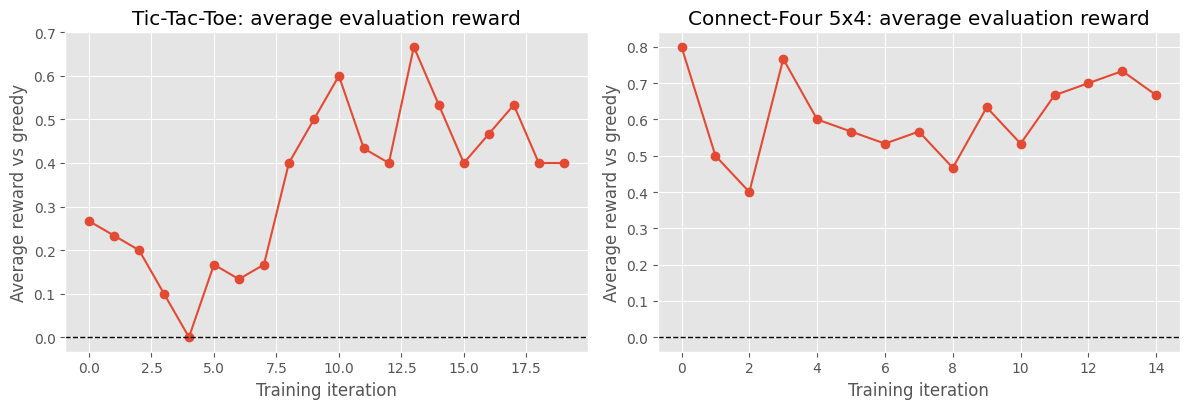

In [ ]:
print(f"{'iter':<6}{'TTT reward':>12}{'C4 reward':>12}")
ttt_reward = np.array(ttt_history["win"]) - np.array(ttt_history["lose"])
c4_reward = np.array(c4_history["win"]) - np.array(c4_history["lose"])
for i in range(max(len(ttt_reward), len(c4_reward))):
    t = f"{ttt_reward[i]:.2f}" if i < len(ttt_reward) else ""
    c = f"{c4_reward[i]:.2f}" if i < len(c4_reward) else ""
    print(f"{i:<6}{t:>12}{c:>12}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, history, name in ((axes[0], ttt_history, "Tic-Tac-Toe"),
                          (axes[1], c4_history, "Connect-Four 5x4")):
    reward = np.array(history["win"]) - np.array(history["lose"])
    ax.plot(range(len(reward)), reward, marker="o")
    ax.axhline(0, linestyle="--", linewidth=1, color="black")
    ax.set_xlabel("Training iteration")
    ax.set_ylabel("Average reward vs greedy")
    ax.set_title(f"{name}: average evaluation reward")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: התגמול חיובי כמעט תמיד ומטפס עם התנודתיות הצפויה מהערכות קצרות מול יריב חלקית-אקראי. חיובי כבר מההתחלה — תרומת החיפוש עצמו; השיפור ההדרגתי אחריו — תרומת הרשת המתאמנת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הקרב המרכזי — רשת מול חיפוש טהור בארבע בשורה: הרשת (60 סימולציות) מול MCTS טהור ב-60, 200 ו-400 — תקציב שווה, פי 3.3 ופי 6.7. תוצאות נשמרות/נטענות (RETRAIN).</p>
</div>

net-mcts(60) vs pure mcts(60): wins 13/40  losses 7/40  draws 20/40
net-mcts(60) vs pure mcts(200): wins 9/40  losses 19/40  draws 12/40
net-mcts(60) vs pure mcts(400): wins 11/40  losses 14/40  draws 15/40


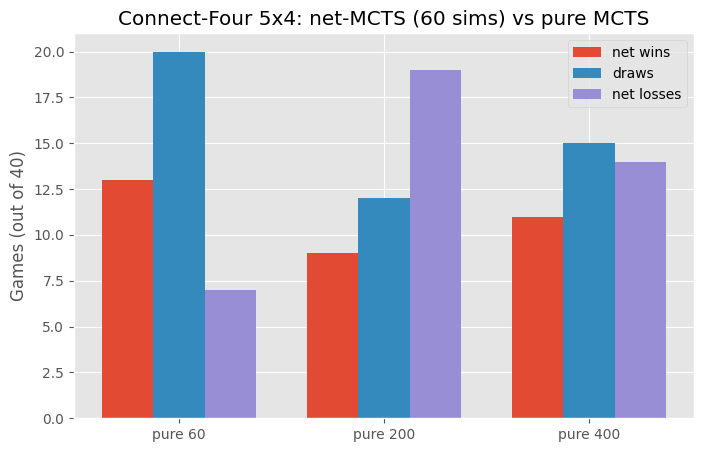

In [ ]:
if RETRAIN:
    head_to_head = {}
    random.seed(SEED)
    for pure_sims in (60, 200, 400):
        wins, losses, draws = two_sided_stats(ConnectFour, mcts_net_player(c4_net, SELFPLAY_SIMS),
                                              mcts_player(pure_sims), 20)
        head_to_head[pure_sims] = (wins, losses, draws)
        print(f"net-mcts(60) vs pure mcts({pure_sims}): wins {wins}/40  losses {losses}/40  draws {draws}/40")
    with open("c4_head_to_head.pkl", "wb") as f:
        pickle.dump(head_to_head, f)
else:
    with open("c4_head_to_head.pkl", "rb") as f:
        head_to_head = pickle.load(f)

labels = [f"pure {s}" for s in head_to_head]
wins = [head_to_head[s][0] for s in head_to_head]
losses = [head_to_head[s][1] for s in head_to_head]
draws = [head_to_head[s][2] for s in head_to_head]
x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.25, wins, width=0.25, label="net wins")
plt.bar(x, draws, width=0.25, label="draws")
plt.bar(x + 0.25, losses, width=0.25, label="net losses")
plt.xticks(x, labels)
plt.ylabel("Games (out of 40)")
plt.title("Connect-Four 5x4: net-MCTS (60 sims) vs pure MCTS")
plt.legend()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: בתקציב שווה הרשת גוברת — 13 נצחונות מול 7 הפסדים. בתקציב פי 3.3 היתרון עובר בבירור לחיפוש הטהור, 19 מול 9. בפי 6.7 החיפוש הטהור עדיין מוביל (14 מול 11), אך הפער מצטמצם יחסית ל-200 — כנראה רעש דגימה על 40 משחקים עם הרבה תיקו. בסביבת האימות, שם קיימת אמת מוחלטת, הרשת איפסה הפסדים לחלוטין ב-200 סימולציות — המגבלה כאן היא היקף האימון, לא השיטה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הצגת המדיניות הנלמדת: טבלאות ומפות חום של הסתברויות ראש המדיניות של הרשת על לוח פתיחה ריק בשני המשחקים, ואחריה משחק הדגמה מלא של הרשת נגד החמדן בארבע בשורה.</p>
</div>

Tic-Tac-Toe opening policy (value 0.40)
  0.29  0.03  0.07
  0.02  0.16  0.05
  0.14  0.03  0.20

Connect-Four opening policy (value -0.23)
  0.28  0.21  0.15  0.14  0.22


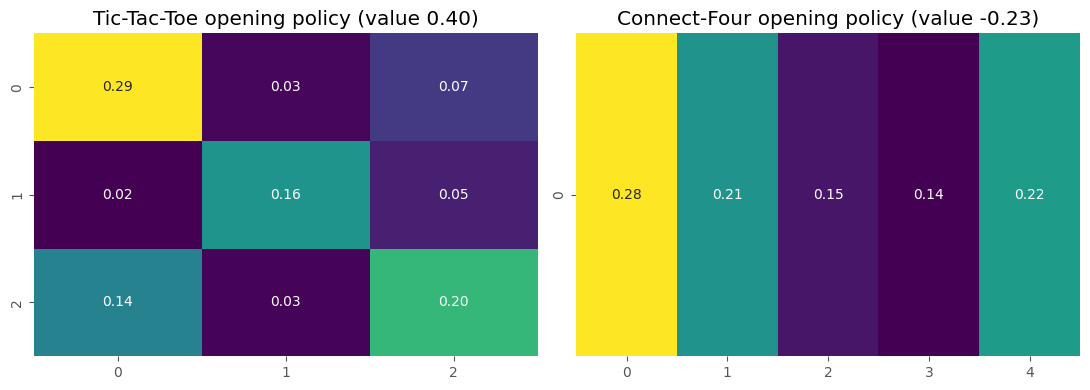

In [ ]:
ttt_priors, ttt_value = net_evaluate(ttt_net, TicTacToe())
c4_priors, c4_value = net_evaluate(c4_net, ConnectFour())

ttt_grid = ttt_priors.cpu().numpy().reshape(3, 3)
print(f"Tic-Tac-Toe opening policy (value {ttt_value:.2f})")
for row in ttt_grid:
    print("  " + "  ".join(f"{v:.2f}" for v in row))

print()
c4_row = c4_priors.cpu().numpy().reshape(C4_COLS)
print(f"Connect-Four opening policy (value {c4_value:.2f})")
print("  " + "  ".join(f"{v:.2f}" for v in c4_row))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(ttt_grid, annot=True, fmt=".2f",
            cmap="viridis", cbar=False, ax=axes[0])
axes[0].set_title(f"Tic-Tac-Toe opening policy (value {ttt_value:.2f})")
sns.heatmap(c4_row.reshape(1, C4_COLS), annot=True, fmt=".2f",
            cmap="viridis", cbar=False, ax=axes[1])
axes[1].set_title(f"Connect-Four opening policy (value {c4_value:.2f})")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>בטבלת איקס עיגול: הפינות והמרכז עם ההסתברות הגבוהה ביותר (0.29, 0.20, 0.16), הצלעות עם הנמוכה ביותר (0.02-0.05) — תואם את התאוריה הקלאסית של המשחק. הערך 0.40 גבוה מהאמת (תיקו, 0) — עקבי עם פיזור הכיול שנבדק קודם. בארבע בשורה: עמודות הקצוות (0.28, 0.22) מובילות על פני האמצע (0.14-0.15), והערך שלילי, -0.23.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>draw_c4_board — מלבן כחול כרקע, עיגול למשבצת: לבן ריק, זהב שחקן 1, אדום שחקן 2. שוליים סביב הלוח חושפים את סגנון ggplot של המחברת. שורה 0 של המטריצה למעלה, כמו בטקסט.</p>
</div>

In [ ]:
def draw_c4_board(ax, board, title=""):
    rows, cols = board.shape
    margin = 0.6
    ax.set_facecolor(plt.rcParams["axes.facecolor"])
    ax.add_patch(plt.Rectangle((-0.5, -0.5), cols, rows, color="#1f4e8c"))
    for r in range(rows):
        for c in range(cols):
            v = int(board[r, c])
            color = "white" if v == 0 else ("gold" if v == 1 else "crimson")
            ax.add_patch(plt.Circle((c, rows - 1 - r), 0.4, color=color))
    ax.set_xlim(-0.5 - margin, cols - 0.5 + margin)
    ax.set_ylim(-0.5 - margin, rows - 0.5 + margin)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>משחק הדגמה מלא בארבע בשורה — הרשת נגד החמדן, בתצוגת טקסט וגרפיקה יחד: אותו משחק בדיוק, פעם כרצף לוחות ASCII ופעם כרצף לוחות מצוירים בזהב וארגמן.</p>
</div>

     . . . . .          . . . . .          . . . . .          . . . . .          . . . . .     
     . . . . .          . . . . .          . . . . .          O . . . .          O . . . .     
 1)  . . . . .      2)  O . . . .      3)  O . . . .      4)  O . . . .      5)  O X . . .     
     X . . . .          X . . . .          X X . . .          X X . . .          X X . . .     

     . . . . .          . . . . .          . . . . .          . . . . .          . O . . .     
     O . . . .          O . . . .          O O . . .          O O . . .          O O . . .     
 6)  O X . . .      7)  O X X . .      8)  O X X . .      9)  O X X . .     10)  O X X . .     
     X X O . .          X X O . .          X X O . .          X X O X .          X X O X .     

     . O . . .          . O O . .          . O O . .          . O O . .          . O O . .     
     O O X . .          O O X . .          O O X . .          O O X . .          O O X . .     
11)  O X X . .     12)  O X X . .     

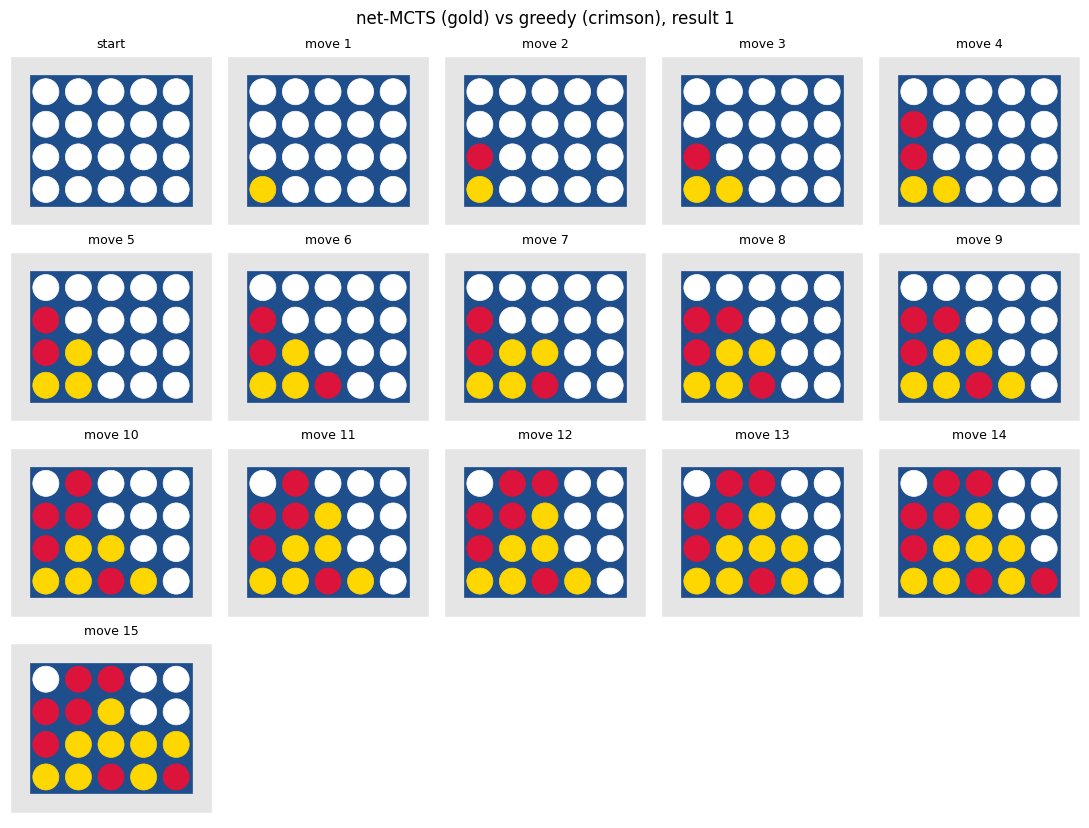

In [ ]:
random.seed(SEED)
game = ConnectFour()
frames = [game.board.copy()]
agents = {1: mcts_net_player(c4_net, SELFPLAY_SIMS), -1: greedy_player}
while game.winner() is None:
    game.play(agents[game.player](game))
    frames.append(game.board.copy())
result = game.winner()

symbols = {1: "X", -1: "O", 0: "."}
rows, cols = frames[0].shape
num_width = len(str(len(frames) - 1))
for start in range(1, len(frames), 5):
    group = list(enumerate(frames))[start:start + 5]
    for r in range(rows):
        line = ""
        for num, board in group:
            row = " ".join(symbols[int(board[r, c])] for c in range(cols))
            prefix = f"{num:>{num_width}})  " if r == rows // 2 else " " * (num_width + 3)
            line += f"{prefix}{row}     "
        print(line)
    print()
print("result:", result)

n_frames = len(frames)
n_cols = 5
n_rows = math.ceil(n_frames / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.1 * n_rows))
for i, ax in enumerate(np.array(axes).flatten()):
    if i < n_frames:
        title = "start" if i == 0 else f"move {i}"
        draw_c4_board(ax, frames[i], title)
    else:
        ax.axis("off")
plt.suptitle(f"net-MCTS (gold) vs greedy (crimson), result {result}")
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: מדיניות פתיחה גולמית היא אות חלש כאן — אין מהלך פתיחה מנצח, וההתפלגות משתנה בין ריצות אימון — אך המדדים התפקודיים (אחוז אופטימלי, תוצאות מול יריבים) יציבים; העוצמה מגיעה מהערכת עמדות בעומק העץ, לא מהעדפת מהלך ראשון. הרצף הגרפי ממחיש את אותו משחק חזותית: שחקן מונחה-חיפוש מול שחקן תגובתי שרואה מהלך אחד קדימה בלבד — והרשת מנצחת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>גרף סיכום — איקס עיגול: ריכוז הפסדים מול שחקן מושלם לארבעת השחקנים העיקריים (MCTS טהור מול מונחה-רשת, בשני תקציבים).</p>
</div>

tic-tac-toe | pure mcts 50: losses vs perfect play 21/60
tic-tac-toe | pure mcts 200: losses vs perfect play 18/60
tic-tac-toe | net mcts 50: losses vs perfect play 5/60
tic-tac-toe | net mcts 200: losses vs perfect play 6/60


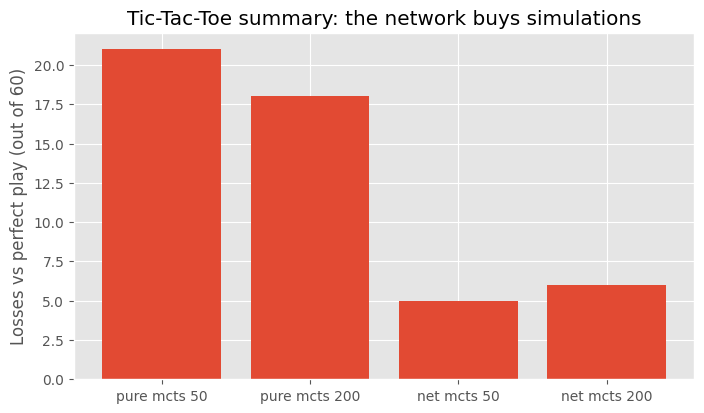

In [ ]:
random.seed(SEED)
summary_rows = []
for agent, name in ((mcts_player(50), "pure mcts 50"),
                    (mcts_player(200), "pure mcts 200"),
                    (mcts_net_player(ttt_net, 50), "net mcts 50"),
                    (mcts_net_player(ttt_net, 200), "net mcts 200")):
    wins, losses, draws = two_sided_stats(TicTacToe, agent, minimax_player, 30)
    summary_rows.append((name, losses))
    print(f"tic-tac-toe | {name}: losses vs perfect play {losses}/60")

names = [row[0] for row in summary_rows]
values = [row[1] for row in summary_rows]
plt.figure(figsize=(8, 4.5))
plt.bar(names, values)
plt.ylabel("Losses vs perfect play (out of 60)")
plt.title("Tic-Tac-Toe summary: the network buys simulations")
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח: באותו תקציב, הרשת מפילה הפסדים מעשרות (21, 18) לבודדים (5, 6) — הפרש קטן בין 50 ל-200 עם הרשת, בטווח רעש הדגימה של 60 משחקים; קרובה לתקרה כבר בתקציב הקטן. אותה מגמה נצפתה בארבע בשורה בקרב הישיר בתקציב שווה. תשובה לשאלת המחקר: ידע נלמד ממיר חישוב — רשת שאומנה בדקות שווה הכפלה ואף יותר של תקציב הסימולציות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מגבלות העבודה ורעיונות לשיפור עתידי:</p>
<ul>
<li>היקף אימון קצר (דקות על מעבד); אימון ארוך יותר, מאגר גדול יותר והערכת שערים בין דורות צפויים לשפר בתקציבים גדולים</li>
<li>הרשת מלאה ופשוטה, לא מנצלת מבנה מרחבי; רשת קונבולוציה צפויה להכליל טוב יותר בלוחות גדולים</li>
<li>ארבע בשורה המוקטן נוטה לתיקו ודוחס את טווח המדידה; לוח 6×7 מלא היה מבחין טוב יותר, במחיר זמן ריצה</li>
<li>לא נוצלו סימטריות הלוח להכפלת הדאטה (שיקוף אופקי ב-C4, שמונה סימטריות באיקס עיגול)</li>
<li>לא נמדד RMSE של ראש הערך לאורך סבבי האימון, רק בסופו</li>
<li>השוואה מול baseline נוסף מהקורס (Q-Learning טבלאי) הייתה ממקמת את התוצאות בהקשר רחב יותר</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>סיכום כולל:</p>
<p>הפרויקט מימש MCTS מאפס, אימת אותו על איקס עיגול מול פתרון מושלם (התכנסות לאפס הפסדים עם גידול התקציב), והדגים בארבע בשורה שליטה ברורה בשחקני הבסיס עם אבלציה רב-זרעית. בשלב 2 נבנתה לולאת למידה ממשחק עצמי בהשראת AlphaZero: רשת policy+value שאומנה בלמידה מפוקחת על תוצרי החיפוש. הרשת צמצמה את ההפסדים מול השחקן המושלם באיקס עיגול לבודדים עד אפס (לעומת כ-20 לחיפוש הטהור באותם תקציבים), וגברה עליו בתקציב שווה בארבע בשורה. הממצא המרכזי: העברת ידע מהחיפוש לפונקציה נלמדת ממירה זמן חישוב בזמן אימון — הרעיון שבבסיס AlphaZero, משוחזר בקטן על לפטופ.</p>
</div>